In [702]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

from sklearn.cluster import KMeans, BisectingKMeans
from sklearn.metrics import silhouette_score

from scipy.spatial.distance import pdist, squareform

from pyclustering.cluster import xmeans

from kneed import KneeLocator

We're going to use the log transformation of runtimeMinutes.

In [668]:
df = pd.read_csv("../results/train_clean.csv", index_col=0)
df['genres'] = df['genres'].apply(ast.literal_eval)
df['logRuntime'] = np.log(df['runtimeMinutes'] + 1)

df.describe()

,startYear,runtimeMinutes,numVotes,totalImages,totalCredits,numRegions,ratingNum,numGenres,criticReviewsRatio,logRuntime
count,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000,16431.000000
mean,1991.867081,58.480494,4.079722,1.302735,3.499824,1.161221,7.155620,1.927332,0.165655,3.817365
std,26.120690,46.475639,1.760203,1.194015,1.111965,0.707212,1.386902,0.830975,0.304980,0.820471
min,1878.000000,0.000000,1.791759,0.000000,0.000000,0.693147,1.000000,1.000000,0.000000,0.000000
25%,1978.000000,29.000000,2.772589,0.693147,2.833213,0.693147,6.000000,1.000000,0.000000,3.401197
50%,1997.000000,50.000000,3.610918,0.693147,3.555348,0.693147,7.000000,2.000000,0.000000,3.931826
75%,2013.000000,90.000000,5.007291,1.945910,4.189655,1.386294,8.000000,3.000000,0.226540,4.510860
max,2024.000000,3000.000000,13.781505,8.161946,9.664151,4.248495,10.000000,3.000000,1.000000,8.006701


In [669]:
numeric_cols = df.dtypes[(df.dtypes == 'float64') | (df.dtypes == 'int64')].index
numeric_df = df[numeric_cols]
numeric_df.drop(['ratingNum', 'runtimeMinutes'], axis=1, inplace=True) #drop ratingNum bc it is the target variable
#numeric_df.drop(['ratingNum'], axis=1, inplace=True) 
numeric_df.head()

C:\Users\camim\AppData\Local\Temp\ipykernel_1712\3860749921.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,startYear,numVotes,totalImages,totalCredits,numRegions,numGenres,criticReviewsRatio,logRuntime
0,1995,6.659294,0.693147,3.091042,0.693147,3,1.000000,3.713572
1,1982,2.484907,0.693147,0.693147,0.693147,1,0.000000,3.367296
2,1992,3.663562,0.693147,3.218876,0.693147,1,0.000000,4.510860
3,2021,2.772589,3.135494,4.043051,0.693147,1,0.000000,3.465736
4,2020,9.662625,5.852202,3.871201,3.496508,3,0.008772,4.394449


In [ ]:
#scaling → MinMaxScaler yields better Silhouette Scores wrt StandardScaler and RobustScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(numeric_df.values)

# K-means

Determining the best K

In [671]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X)) #Euclidean distance

for k in range(2, 51): 
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    kmeans.fit(X)
    sse_list.append(kmeans.inertia_) #sse
    sil_list.append(silhouette_score(dist, kmeans.labels_, metric='precomputed'))

CPU times: total: 3min 46s
Wall time: 1min 56s


In [672]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 11


In [673]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 7, score = 0.3464116064027605
k = 6, score = 0.3428147395021794
k = 3, score = 0.3387137569198243
k = 8, score = 0.3383060431106167
k = 5, score = 0.3286861041058108
k = 2, score = 0.32301617980585484
k = 4, score = 0.29912491644791034
k = 9, score = 0.2872449536537791
k = 11, score = 0.28624919313620995
k = 10, score = 0.2837020366705708
k = 12, score = 0.2836123234657372
k = 13, score = 0.2662850961920158
k = 15, score = 0.2575206626619666
k = 14, score = 0.2572222566289659
k = 17, score = 0.25153101947668705


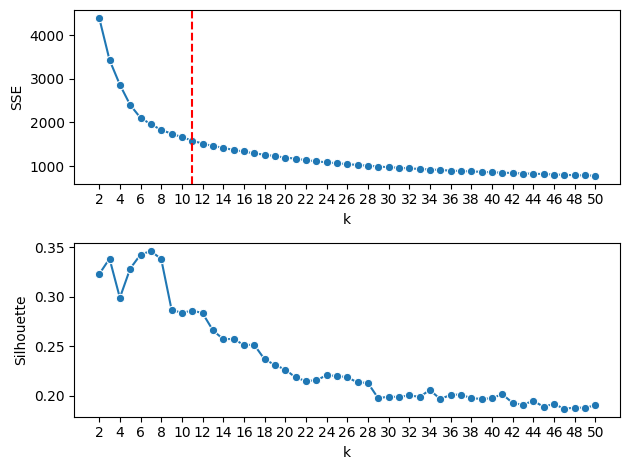

In [674]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))

plt.tight_layout()

## k = 8
We choose 8 as a trade off between SSE and Silhouette Score.

In [675]:
k = 8

In [676]:
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
kmeans.fit(X)

KMeans(max_iter=100, n_init=10, random_state=42)

In [677]:
labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', kmeans.inertia_)
print('Silhouette score:', silhouette_score(X, kmeans.labels_))

Cluster sizes:
Cluster 0:	3032
Cluster 1:	916
Cluster 2:	4925
Cluster 3:	1367
Cluster 4:	3398
Cluster 5:	967
Cluster 6:	1044
Cluster 7:	782

SSE: 1829.9016591518616
Silhouette score: 0.3383060431106134


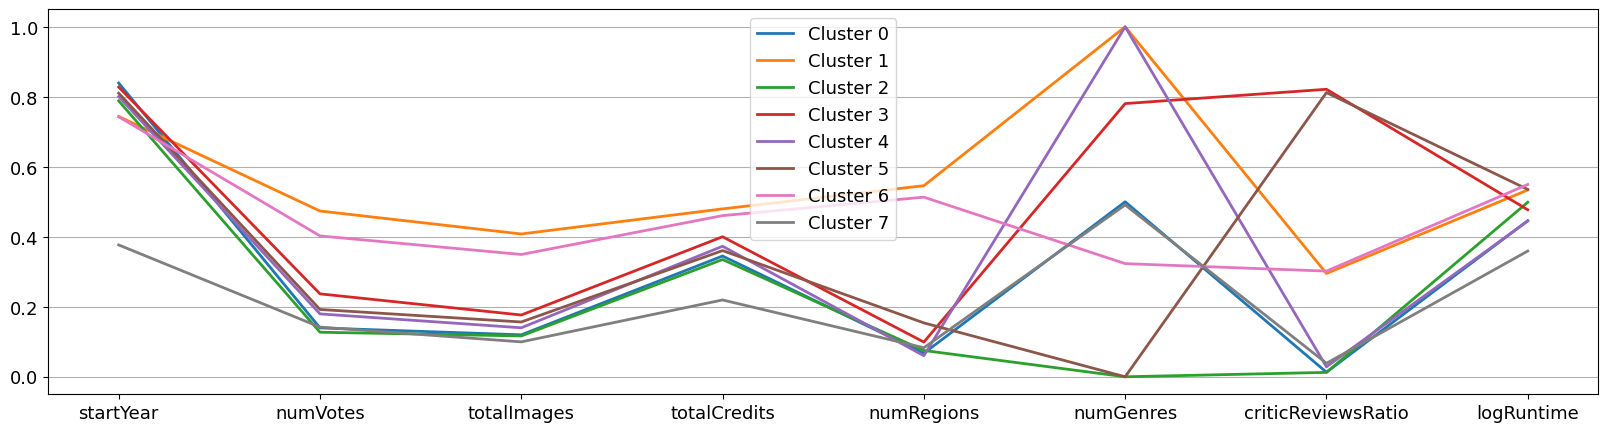

In [678]:
plt.figure(figsize=(20, 5))
centers = kmeans.cluster_centers_
for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Clusters separate points mostly based on `numGenres`. Quite separated based on `numVotes`, `totalImages`, `totalCredits`, as well as `criticReviesRatio` and `logRuntime`. Cluster 7 is particularly separated from the others based on `startYear`.


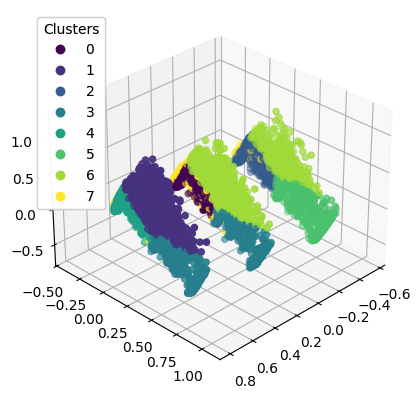

In [679]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3) 
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'])
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=30., azim=45)

plt.show()

## K means with selected features

Using all numerical features does not yield great results. Based on our insights from the data understanding phase, we disregard `totalImages`, `numRegions` and `totalCredits` bc they are moderately correlated w/ `numVotes`, to see if using less features provides a more meaningful clustering.

In [680]:
numeric_df = df[numeric_cols]
numeric_df.drop(['ratingNum', 'runtimeMinutes', 'totalImages', 'numRegions', 'totalCredits'], axis=1, inplace=True)
numeric_df.head()

C:\Users\camim\AppData\Local\Temp\ipykernel_1712\2205704909.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,startYear,numVotes,numGenres,criticReviewsRatio,logRuntime
0,1995,6.659294,3,1.000000,3.713572
1,1982,2.484907,1,0.000000,3.367296
2,1992,3.663562,1,0.000000,4.510860
3,2021,2.772589,1,0.000000,3.465736
4,2020,9.662625,3,0.008772,4.394449


In [681]:
scaler = MinMaxScaler()
X = scaler.fit_transform(numeric_df.values)

In [682]:
%%time
sse_list = []
sil_list = []
dist = squareform(pdist(X))

for k in range(2, 51): 
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
    kmeans.fit(X)
    sse_list.append(kmeans.inertia_) #sse
    sil_list.append(silhouette_score(dist, kmeans.labels_, metric='precomputed'))

CPU times: total: 3min 12s
Wall time: 1min 44s


In [683]:
k_values = list(range(2, 51))  
knee_locator = KneeLocator(k_values, sse_list, curve='convex', direction='decreasing')
print(f"Elbow: {knee_locator.knee}")

Elbow: 11


In [684]:
coeffs = np.array(sil_list)
top_indices = np.argsort(coeffs)[::-1][:15]
top_scores = np.sort(coeffs)[::-1][:15] 

print("Top 15 best k values for silhouette score:")
for k, score in zip(top_indices, top_scores):
    print(f"k = {k+2}, score = {score}") #adjust k value to start from 2

Top 15 best k values for silhouette score:
k = 8, score = 0.4435024182627778
k = 5, score = 0.43746739700569054
k = 6, score = 0.4374531446971164
k = 7, score = 0.4309525195343286
k = 3, score = 0.4265686385396826
k = 4, score = 0.41705260812152856
k = 11, score = 0.40040026363548215
k = 2, score = 0.3960788253206585
k = 10, score = 0.3947986080643655
k = 9, score = 0.39435519364779864
k = 12, score = 0.38375498586560675
k = 15, score = 0.356212330214009
k = 13, score = 0.3511012558927335
k = 14, score = 0.35083132152986063
k = 16, score = 0.3342082381099915


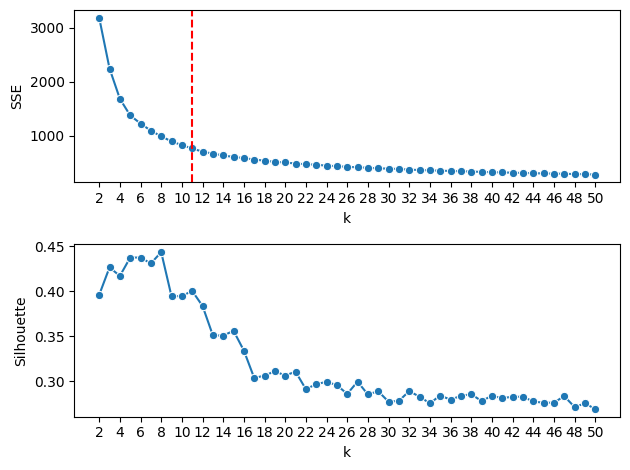

In [685]:
fig, axs = plt.subplots(2) 

sns.lineplot(x=k_values, y=sse_list, marker='o', ax=axs[0])
axs[0].set(xlabel='k', ylabel='SSE')
axs[0].axvline(knee_locator.knee, color='r', linestyle='--')
axs[0].set_xticks(np.arange(2,51,2))

sns.lineplot(x=k_values, y=sil_list, marker='o', ax=axs[1])
axs[1].set(xlabel='k', ylabel='Silhouette')
axs[1].set_xticks(np.arange(2,51,2))

plt.tight_layout()

We select k = 8. We do get a better SSE and Silhouette Score.

In [686]:
k = 8

In [687]:
kmeans = KMeans(n_clusters=k, n_init=10, max_iter=100, random_state=42)
kmeans.fit(X)

KMeans(max_iter=100, n_init=10, random_state=42)

In [688]:
labels, counts = np.unique(kmeans.labels_, return_counts=True)
print("Cluster sizes:")
for label, count in zip(labels,counts):
    print(f"Cluster {label}:\t{count}")

print('\nSSE:', kmeans.inertia_)
print('Silhouette score:', silhouette_score(X, kmeans.labels_))

Cluster sizes:
Cluster 0:	3020
Cluster 1:	865
Cluster 2:	853
Cluster 3:	1360
Cluster 4:	1076
Cluster 5:	935
Cluster 6:	5115
Cluster 7:	3207

SSE: 989.7107605386069
Silhouette score: 0.4435024182627597


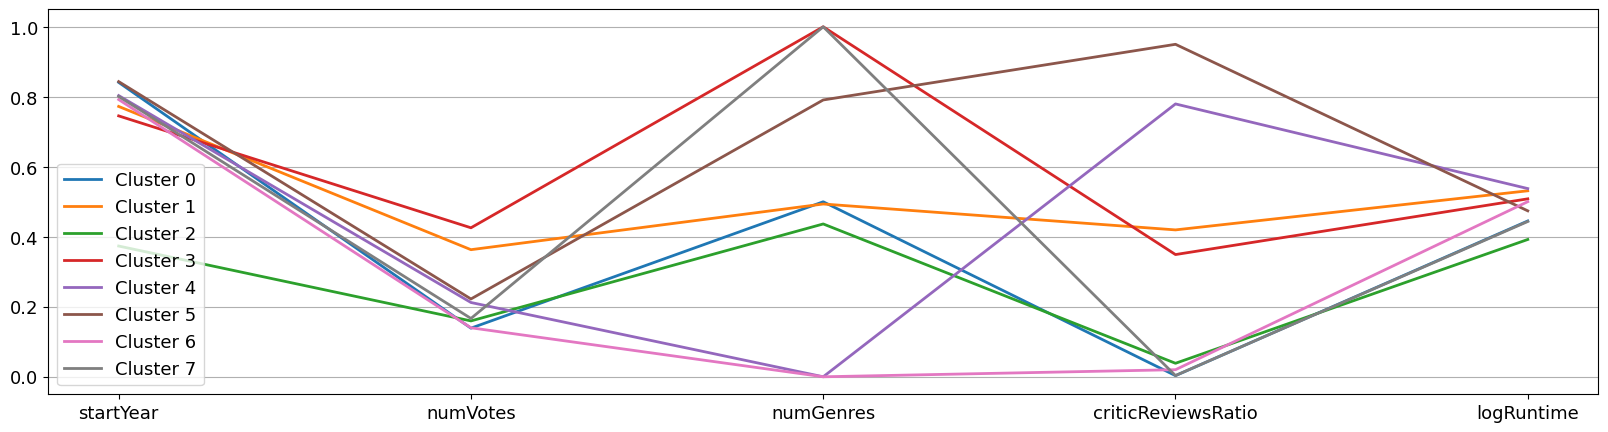

In [689]:
plt.figure(figsize=(20, 5))
centers = kmeans.cluster_centers_
for i in range(len(centers)):
    plt.plot(range(0, len(numeric_df.columns)), centers[i], label='Cluster %s' % i, linewidth=2)
    
plt.xticks(range(0, len(numeric_df.columns)), numeric_df.columns, fontsize=13)
plt.yticks(fontsize=13)

plt.legend(fontsize=13, loc='best')
plt.grid(axis='y')

plt.show()

Again, clusters separate points mostly based on `numGenres` and `criticReviesRatio`. Quite separated based on `numVotes`, and `logRuntime`. Cluster 2 is particularly separated from the others based on `startYear`.


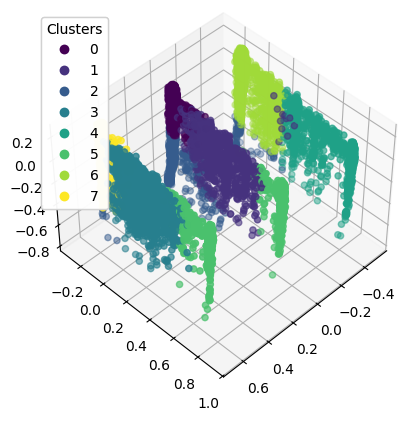

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)  # Initialize a PCA model with 2 components
pca_data = pd.DataFrame(pca.fit_transform(X),columns=['PC1','PC2','PC3'])
pca_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(pca_data['PC1'],pca_data['PC2'],pca_data['PC3'],c=pca_data['cluster'])
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=45, azim=45)

plt.show()

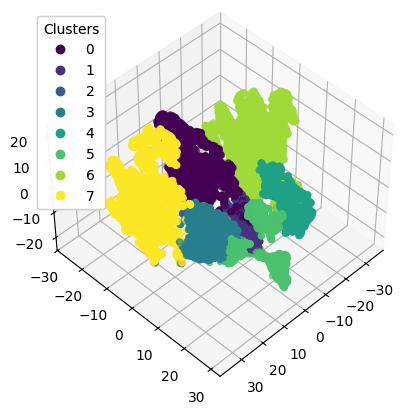

In [691]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=30, random_state=42)
tsne_data = pd.DataFrame(tsne.fit_transform(X), columns=['TSNE1', 'TSNE2', 'TSNE3'])
tsne_data['cluster'] = pd.Categorical(kmeans.labels_)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

scatter = ax.scatter(tsne_data['TSNE1'], tsne_data['TSNE2'], tsne_data['TSNE3'], c=tsne_data['cluster'])
ax.add_artist(ax.legend(*scatter.legend_elements(), loc="upper left", title="Clusters"))
ax.view_init(elev=45, azim=45)

plt.show()

### Qualitative Evaluation
We visualize the distribution of the clusters against interesting known categorical features. The distribution doesn't show pure clusters against any of them, but there are some small insights:
- `titleType`: clusters 0, 2 and 7 show a relevant proportion of shorts. It makes sense, since their centroids are characterised by a lower value for `logRuntime` wrt the other clusters. Clusters 3 and 5 also show a relevant portion of tvEpisodes, but not of shorts. Clusters 4 and 1 are made up by more than 50% movies; their centroids show the highest values for `logRuntime`.
- `ratingNum`: all clusters follow a normal distribution wrt to the rating.
- `canHaveEpisodes`: most of the True records are in the biggest cluster, Cluster 6. For every cluster, they represent a small proportion. Not informative.
- `moreCountriesOfOrigin`: not very informative, True represent a small portion for every cluster, but this is especially true for Cluster 2.
- `awardsAndNominations`: Cluster 2 is characterised by being almost entirely made of records with no awards nor nominations.
- `hasVideos`: the proportion of True is negligible for Cluster 2, whereas Cluster 3 has the most number of True out of any other cluster, showing a significantly higher proportion.

A consequent characterization emerges for Cluster 2: it mostly contains shorts; it makes sense that they are produced in just one country, they have mostly no awards nor nominations (we could expect movies and tv series to gain more accolades) and also almost no video content on their page.



In [694]:
df_clusters = df.copy()
df_clusters['Labels'] = kmeans.labels_ #add cluster labels

In [695]:
#categorical_feats = ["originalTitle", "titleType", "countryOfOrigin", "genres",  "ratingNum", "canHaveEpisodes", "hasVideos", "moreCountriesOfOrigin"]
categorical_feats = ["titleType","ratingNum", "canHaveEpisodes", "hasVideos", "moreCountriesOfOrigin", "awardsAndNominations"]

In [ ]:
"""
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters[cat], df_clusters['Labels'])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel(cat)
    plt.ylabel('Count')
    plt.legend(title='Cluster')
    plt.show()"
"""

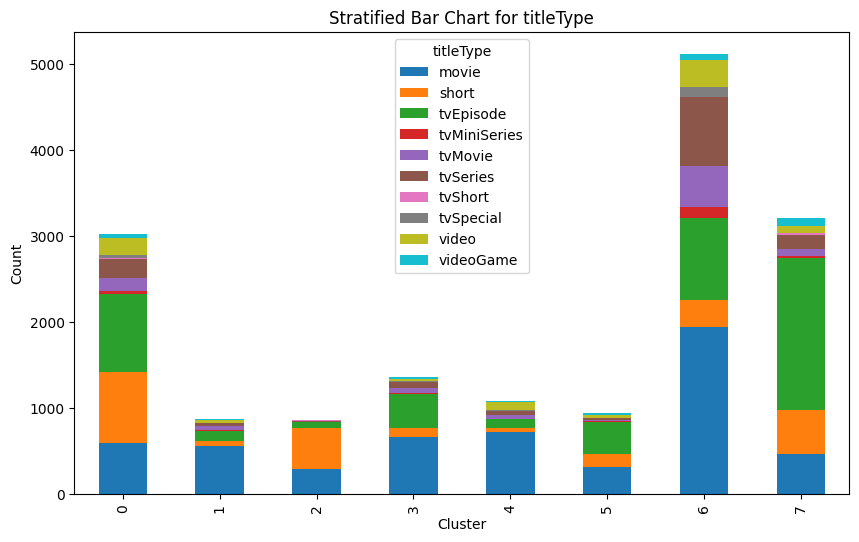

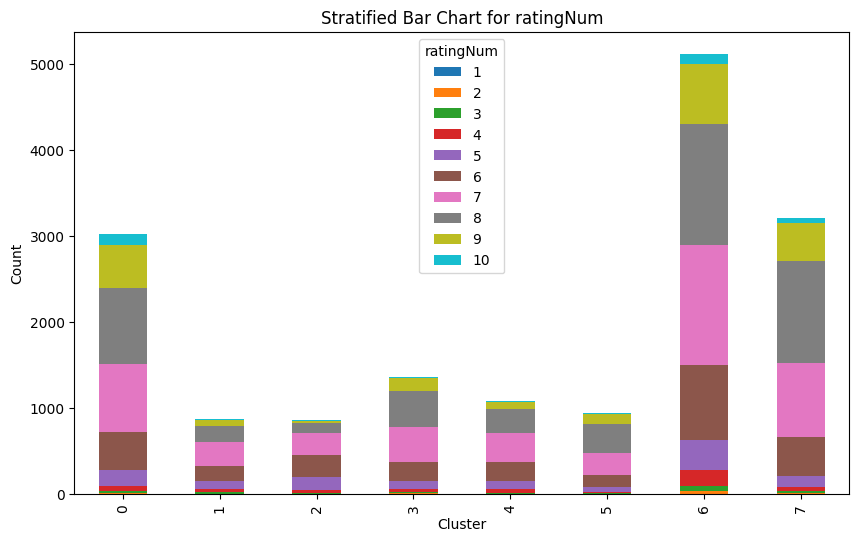

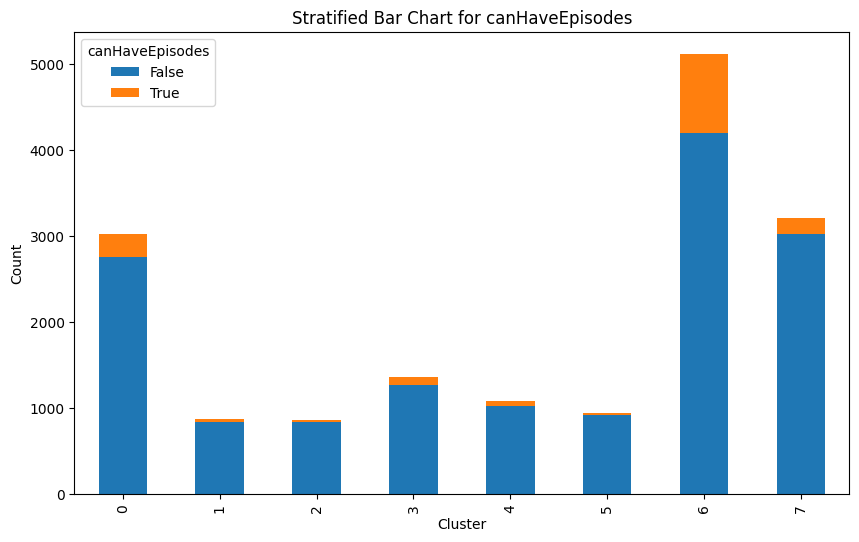

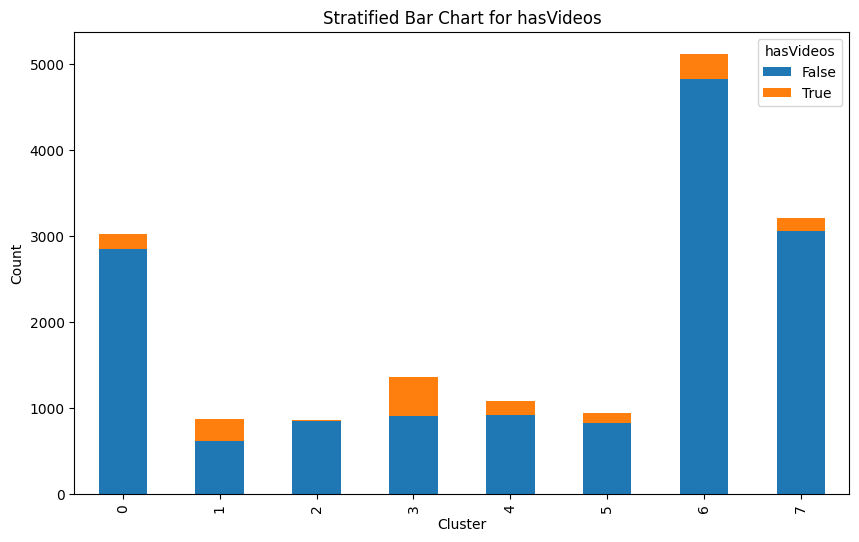

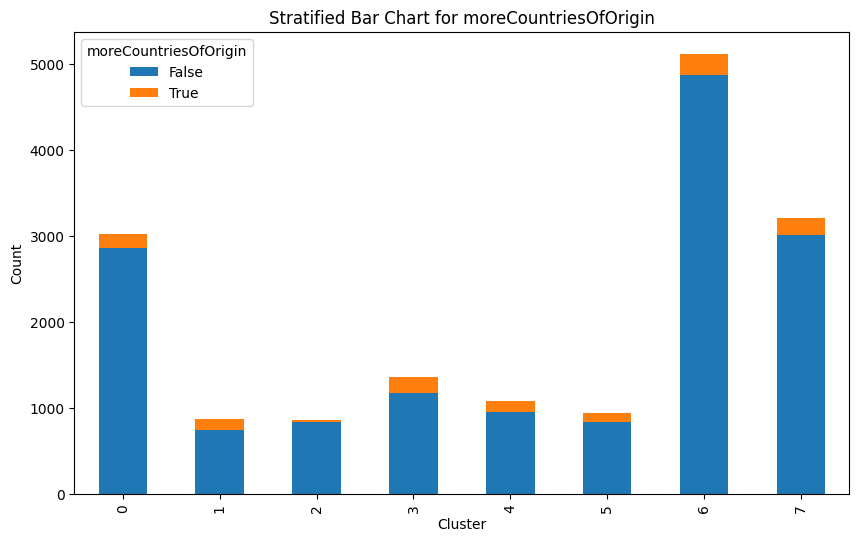

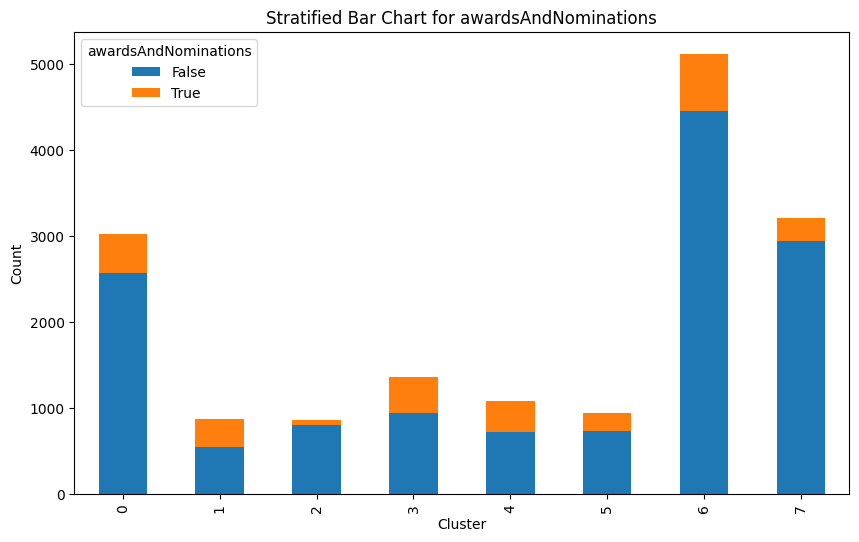

In [697]:
for cat in categorical_feats:
    ct = pd.crosstab(df_clusters['Labels'], df_clusters[cat])
    ct.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title(f'Stratified Bar Chart for {cat}')
    plt.xlabel("Cluster")
    plt.ylabel('Count')
    plt.legend(title=cat)
    plt.show()

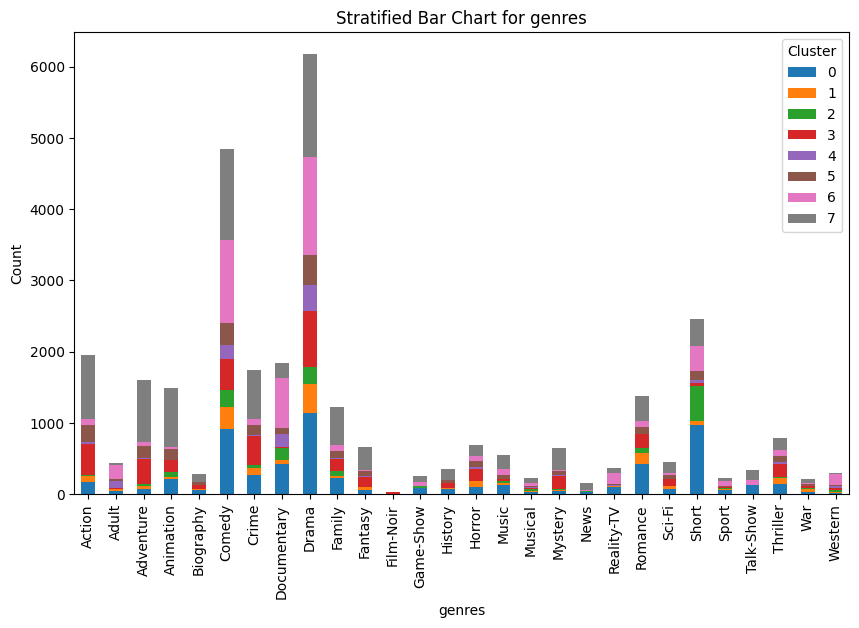

In [ ]:
#not very informative
df_clusters_expl = df_clusters.explode('genres')

ct = pd.crosstab(df_clusters_expl["genres"], df_clusters_expl['Labels'])
ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title(f'Stratified Bar Chart for genres')
plt.xlabel('genres')
plt.ylabel('Count')
plt.legend(title='Cluster')
plt.show()

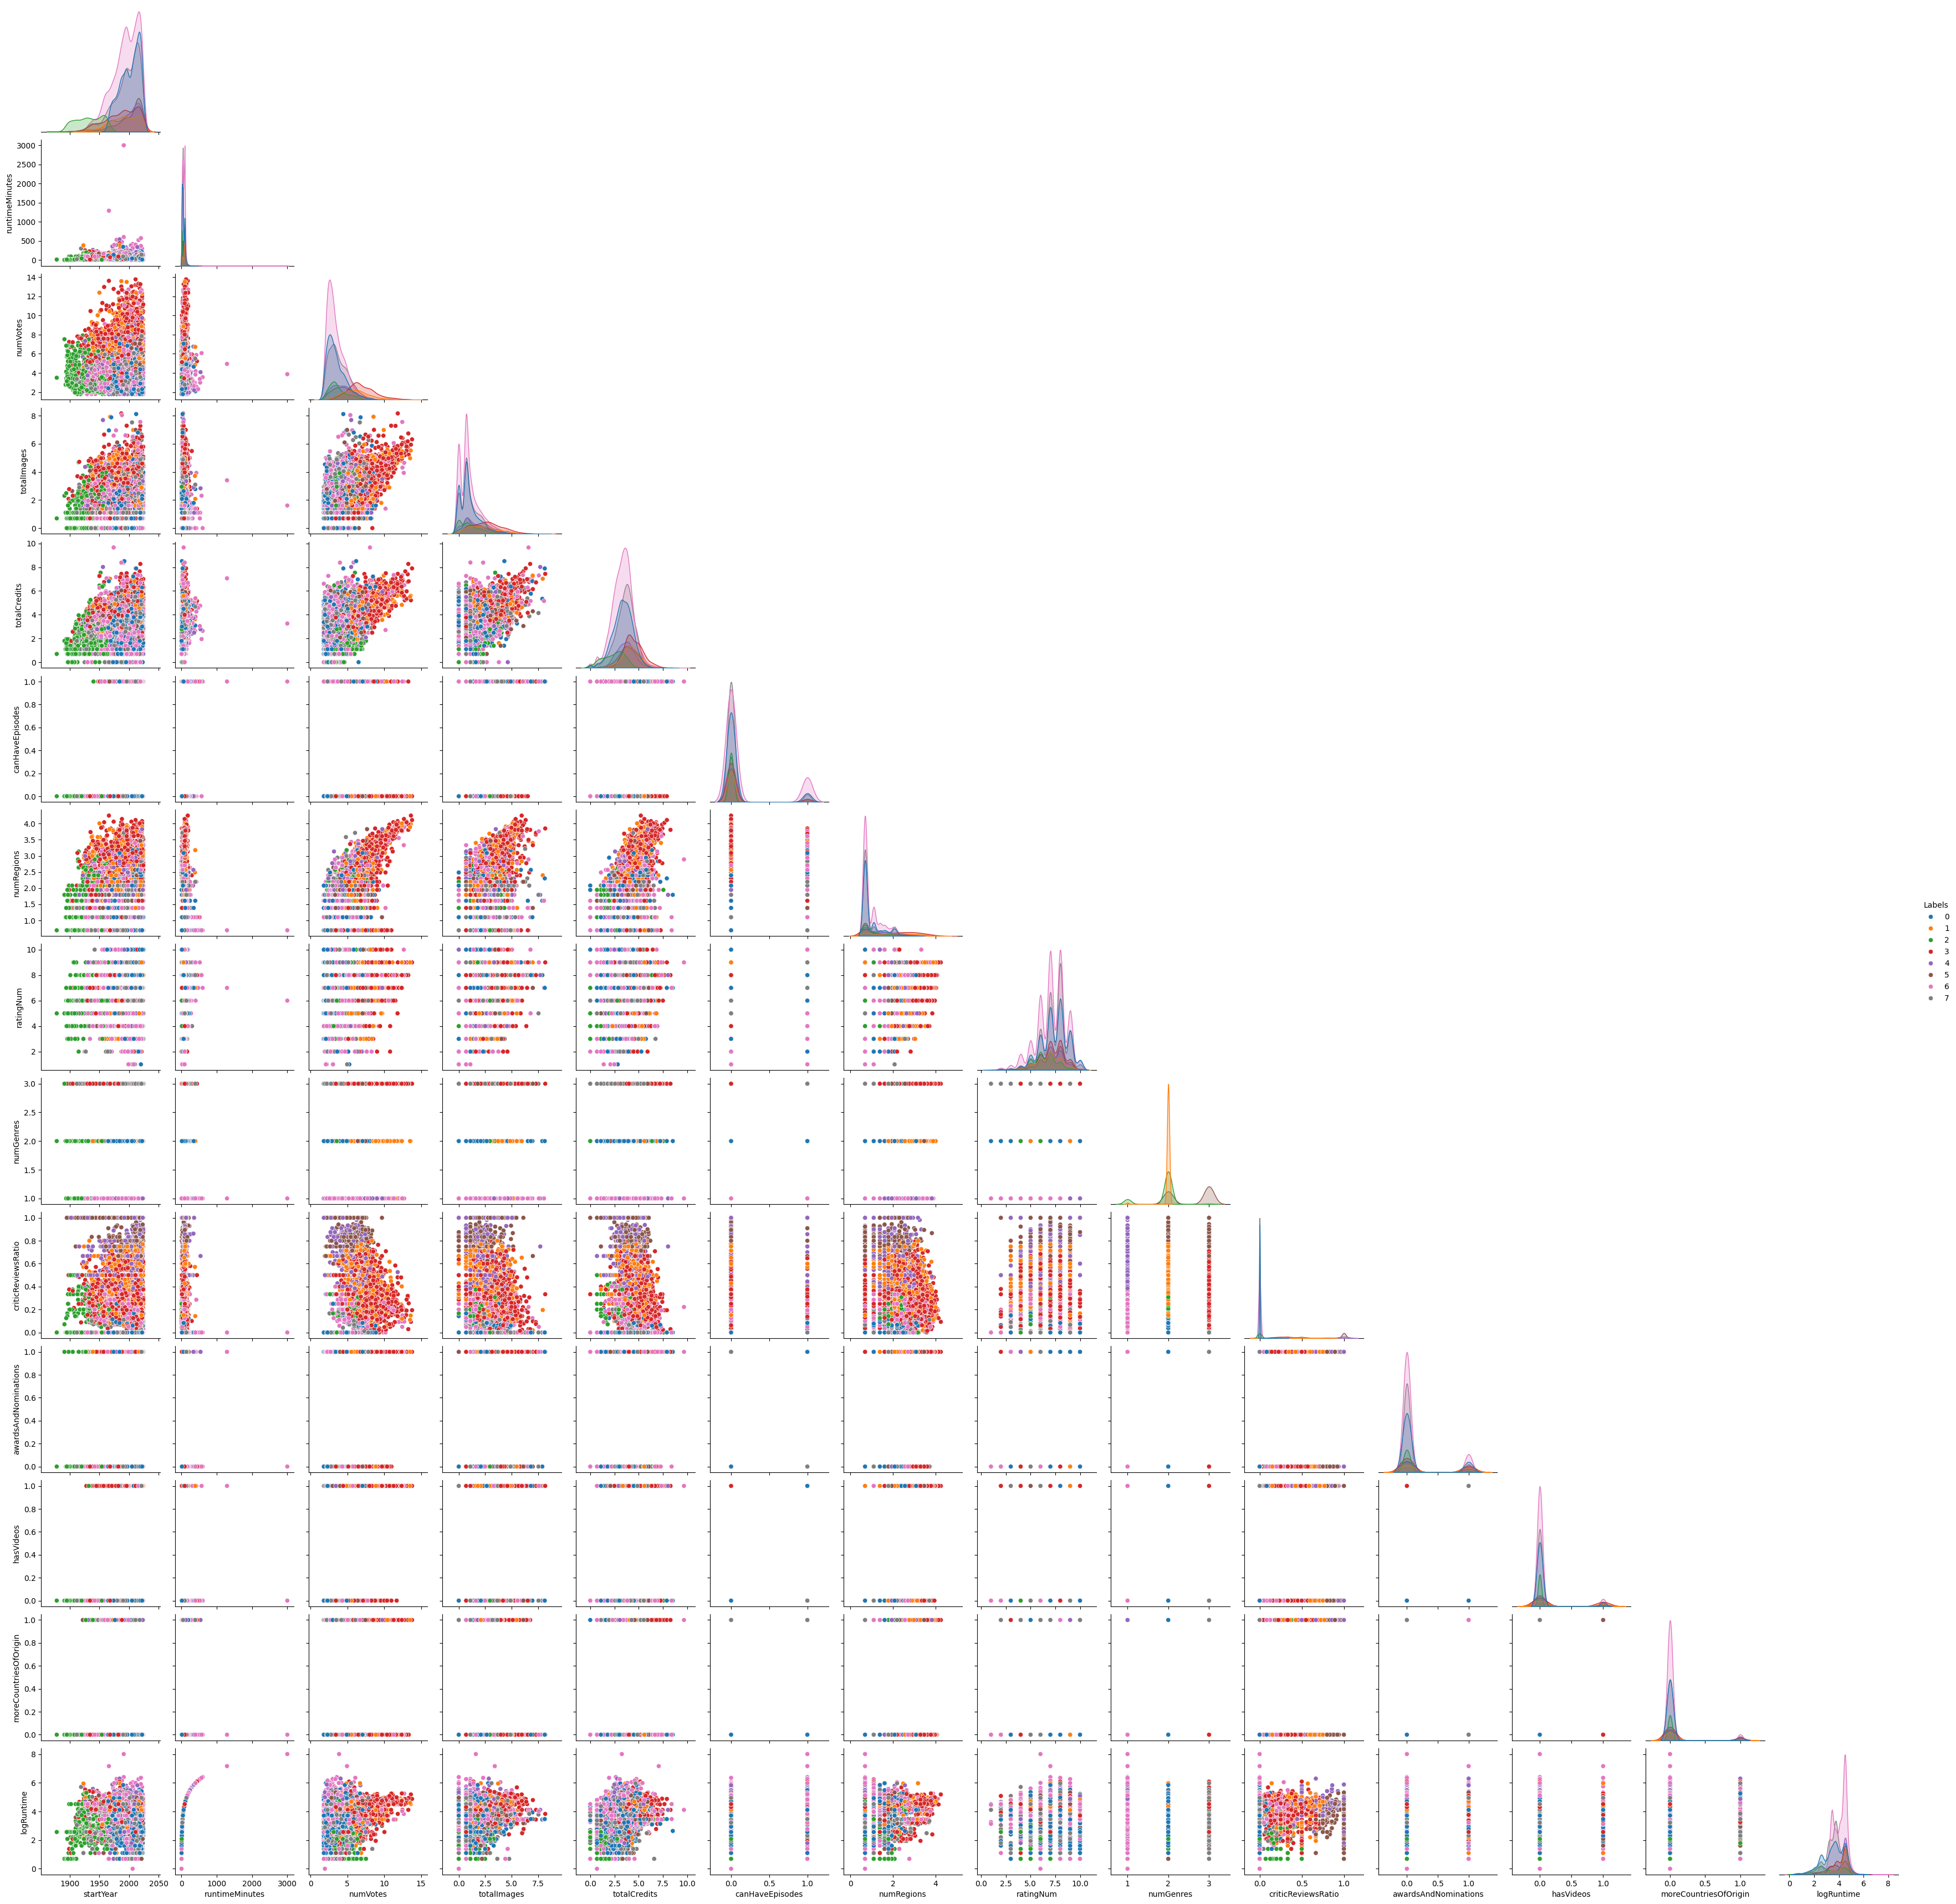

In [699]:
sns.pairplot(df_clusters, hue='Labels', diag_kind='kde', height=2.5, palette='tab10', corner=True)

Let's look at the clusters' composition wrt the numeric variables used by the algorithms.

As hinted by the parallel coordinates plot of the centroid and the PCA visualization, the clusters are mainly separated on the basis of `numGenres`.
- Pure or almost pure clusters:
    - 0 and 1: 2 genres (Cluster 1 has a negligible proportion of 1 genre)
    - 3 and 7: 3 genres
    - 4 and 6: 1 genre.
- Non-pure clusters:
    - 2: mostly 2 genres, small proportion of 1 genre, negligible proportion of 3 genres.
    - 5: around 60% 3 genres and 40% 2 genres.


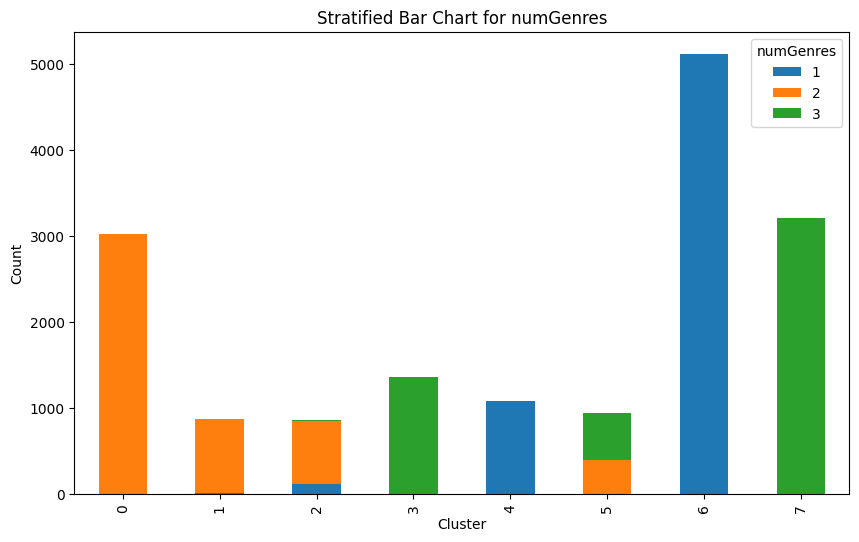

In [700]:
ct = pd.crosstab(df_clusters['Labels'], df_clusters['numGenres'])
ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title(f'Stratified Bar Chart for numGenres')
plt.xlabel("Cluster")
plt.ylabel('Count')
plt.legend(title="numGenres")
plt.show()

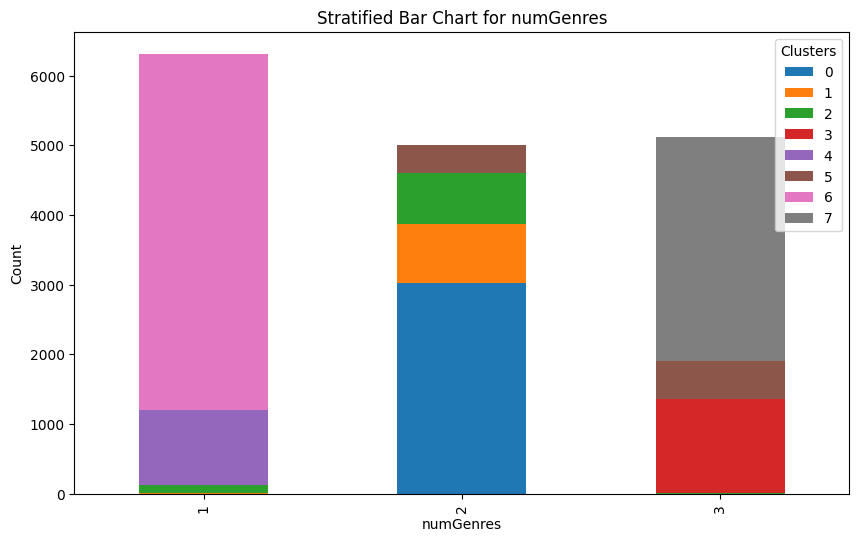

In [701]:
ct = pd.crosstab(df_clusters['numGenres'], df_clusters['Labels'])
ct.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title(f'Stratified Bar Chart for numGenres')
plt.xlabel("numGenres")
plt.ylabel('Count')
plt.legend(title="Clusters")
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clusters, 
    x="numGenres", 
    y="criticReviewsRatio", 
    hue="Labels",  # Colore per cluster
    palette="tab10"
)
plt.xlabel("Clusters")
plt.title("Boxplot of criticReviewsRatio")

The distribution of the clusters wrt to `criticReviewsRatio` is also interesting.
- Cluster 5 is concentrated at 1.0: the reviews are mostly by critics.
- Cluster 4 also has a high ratio.
- Clusters 1 and 3 show variability, but they are a mostly balanced mix of critic and user reviews. They could represent mainstream content.
- Clusters 0, 2, 6 and 7 are skewed towards 0: their reviews are mostly made by the public. They could represent niche or user driven content (indie or fan-made media).

C:\Users\camim\AppData\Local\Temp\ipykernel_1712\3285363681.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




Text(0.5, 1.0, 'Boxplot of criticReviewsRatio')

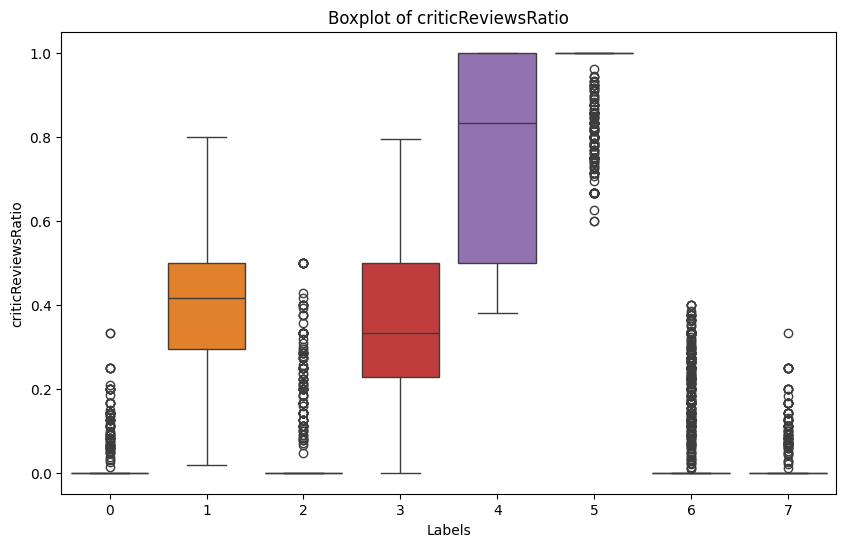

In [762]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clusters, 
    x="Labels", 
    y="criticReviewsRatio", 
    palette="tab10",
    order=sorted(df_clusters['Labels'].unique())
)
plt.title("Boxplot of criticReviewsRatio")


Based on this, we can better visualize the distribution of the clusters wrt the other variables.

- `startYear`: Cluster 2 is separated by the others bc it contains older titles. Clusters 1,6,7 contain titles starting from 1920.
- `logRuntime`: Cluster 2 is characterized by a lower runtime.

In [ ]:
import plotly.express as px
# from itertools import combinations

# all possible pairings of numerical columns used
pairings = [
    ['startYear', 'numVotes'],
['startYear', 'criticReviewsRatio'],
['startYear', 'logRuntime'],
['numVotes', 'criticReviewsRatio'],
['numVotes', 'logRuntime'],
['criticReviewsRatio', 'logRuntime']

]
df_clusters["Labels"] = df_clusters["Labels"].astype(str)
for pair in pairings:
    fig = px.scatter_3d(df_clusters, x='numGenres', y= pair[0], z=pair[1], color='Labels', color_discrete_sequence=px.colors.qualitative.Set1)
    fig.show()

### Statistical evaluation
Our clustering's SSE is significantly lower than the SSE found in the clustering of 500 randomly generated datasets, which suggests that the clusters found by K-Means in our dataset are meaningful and not a product of chance.

In [703]:
my_sse = kmeans.inertia_
my_sse

989.7107605386069

In [709]:
N = 500
sse_stats = []

for _ in range(N):
    Xi = np.zeros(shape=X.shape)
    
    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min, max, nor = np.min(col), np.max(col), len(col)
        Xi[:, cidx] = np.random.uniform(min, max, (1, nor))
    
    kmeans = KMeans(n_clusters=8, n_init=10, max_iter=100, random_state=94)
    kmeans.fit(Xi)
    sse_stats.append(kmeans.inertia_)

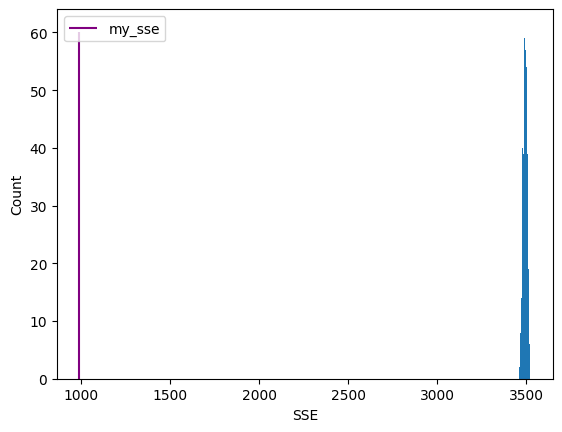

In [710]:
plt.hist(sse_stats, bins='auto')
plt.vlines(x = my_sse, ymin = 0, ymax = 60, colors = 'purple', label = 'my_sse')
plt.xlabel('SSE')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
#using random.normal
N = 500
sse_stats = []

for _ in range(N):
    Xi = np.zeros_like(X)
    
    for cidx in range(Xi.shape[1]):
        col = X[:, cidx]
        min_val, max_val = np.min(col), np.max(col)
        nor = len(col)
        
        mu = (min_val + max_val) / 2
        sigma = (max_val - min_val) / 4  # standard deviation

        Xi[:, cidx] = np.random.normal(mu, sigma, nor)  # Corrected shape
    
    kmeans = KMeans(n_clusters=8, n_init=10, max_iter=100, random_state=94)
    kmeans.fit(Xi)
    sse_stats.append(kmeans.inertia_)


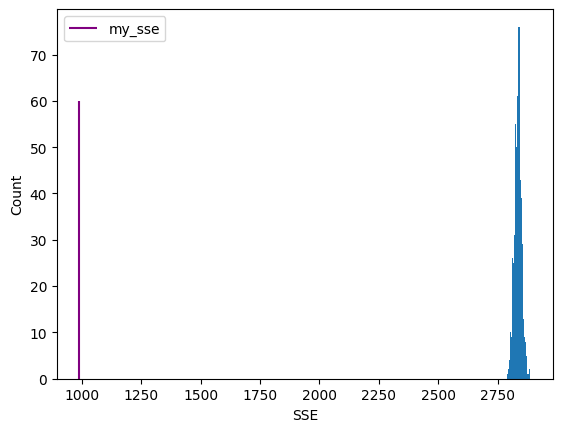

In [712]:
plt.hist(sse_stats, bins='auto')
plt.vlines(x = my_sse, ymin = 0, ymax = 60, colors = 'purple', label = 'my_sse')
plt.xlabel('SSE')
plt.ylabel('Count')
plt.legend()
plt.show()

# Bisecting K-means

# X-Means